# 🔵 Notebook 02 — Customer Segmentation
### Telecom Churn Intelligence + LLM Retention Engine

**Goal:** Group customers into meaningful segments based on their behavior and usage patterns.

**Technique:** KMeans Clustering

**Input:** Cell2Cell training dataset (51,047 customers)

**Output:** Each customer assigned to a labeled segment — used in Notebook 03 to compute churn risk per segment.

---

## 0. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Libraries imported')

✅ Libraries imported


## 1. Load and Prepare Data

In [3]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/jpacse/datasets-for-churn-telecom/cell2celltrain.csv')

# Fix TotalCharges type issue if present
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

from sklearn.impute import KNNImputer

# Separate numeric and categorical
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include='object').columns

# Fill categorical with mode first (KNN only works on numbers)
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# KNN impute numerical columns
imputer = KNNImputer(n_neighbors=5)
df[num_cols] = imputer.fit_transform(df[num_cols])

print(f'Missing values remaining: {df.isnull().sum().sum()}')
print('✅ Missing values handled with KNN imputer')
print(f'Shape: {df.shape}')


Missing values remaining: 0
✅ Missing values handled with KNN imputer
Shape: (51047, 59)


## 2. Select Features for Segmentation

We use behavioral and usage features — these best represent how a customer actually uses the service.
We drop `MonthlyRevenue` due to multicollinearity with `MonthlyMinutes` (confirmed by PCA in Notebook 01).

In [4]:
# Features chosen based on EDA findings in Notebook 01
seg_features = [
    'MonthlyMinutes',        # How much the customer uses the service
    'TotalRecurringCharge',  # What plan they are on
    'CustomerCareCalls',     # How often they contact support
    'RetentionCalls',        # How many times retention team called them
    'Handsets',              # Number of devices on account
    'MonthsInService',       # Customer loyalty / tenure
    'OverageMinutes',        # Usage beyond plan limit
    'DroppedCalls',          # Network experience quality
]

# Keep only features that exist in this dataset
seg_features = [f for f in seg_features if f in df.columns]
print(f'Using {len(seg_features)} features for segmentation:')
for f in seg_features:
    print(f'  - {f}')

X = df[seg_features].copy()

Using 8 features for segmentation:
  - MonthlyMinutes
  - TotalRecurringCharge
  - CustomerCareCalls
  - RetentionCalls
  - Handsets
  - MonthsInService
  - OverageMinutes
  - DroppedCalls


In [5]:
# ── IQR Capping — best treatment before KMeans ────────────────
def cap_outliers_iqr(df, features):
    df_capped = df.copy()
    report = []
    for col in features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_total = ((df[col] < lower) | (df[col] > upper)).sum()
        df_capped[col] = df[col].clip(lower, upper)
        report.append({'Feature': col, 'Total Capped': n_total,
                       'Capped %': round(n_total / len(df) * 100, 2)})
    return df_capped, pd.DataFrame(report)

X_capped, report_df = cap_outliers_iqr(df, seg_features)
print(report_df.to_string(index=False))
print(f'\n✅ All {len(df):,} rows kept — extreme values clipped only')

             Feature  Total Capped  Capped %
      MonthlyMinutes          2582      5.06
TotalRecurringCharge           824      1.61
   CustomerCareCalls          6721     13.17
      RetentionCalls          1745      3.42
            Handsets          4414      8.65
     MonthsInService          1218      2.39
      OverageMinutes          5851     11.46
        DroppedCalls          3712      7.27

✅ All 51,047 rows kept — extreme values clipped only


## 3. Scale the Features

KMeans uses distance to group customers. If one feature has values 0-1000 and another 0-5, the large-scale feature dominates unfairly. StandardScaler brings all features to the same scale.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=seg_features)

print('Before scaling — MonthlyMinutes:')
print(f'  Mean: {X["MonthlyMinutes"].mean():.1f}, Std: {X["MonthlyMinutes"].std():.1f}')
print()
print('After scaling — MonthlyMinutes:')
print(f'  Mean: {X_scaled["MonthlyMinutes"].mean():.4f}, Std: {X_scaled["MonthlyMinutes"].std():.4f}')
print()
print('✅ All features now have mean ≈ 0 and std ≈ 1')

Before scaling — MonthlyMinutes:
  Mean: 525.0, Std: 529.6

After scaling — MonthlyMinutes:
  Mean: -0.0000, Std: 1.0000

✅ All features now have mean ≈ 0 and std ≈ 1


## 4. Find the Optimal Number of Clusters

We use two methods:
- **Elbow Method**: plot inertia (within-cluster sum of squares) — look for the "elbow" where improvement slows
- **Silhouette Score**: measures how well-separated clusters are (higher = better, max = 1)

In [7]:
inertias = []
silhouette_scores = []
K_range = range(2, 10)

print('Testing K values...')
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    silhouette_scores.append(sil)
    print(f'  K={k}: Inertia={km.inertia_:,.0f} | Silhouette={sil:.4f}')

print('\n✅ Done')

Testing K values...
  K=2: Inertia=326,801 | Silhouette=0.4201
  K=3: Inertia=282,688 | Silhouette=0.4340
  K=4: Inertia=250,868 | Silhouette=0.2560
  K=5: Inertia=228,352 | Silhouette=0.2626
  K=6: Inertia=211,487 | Silhouette=0.2172
  K=7: Inertia=195,366 | Silhouette=0.2242
  K=8: Inertia=183,345 | Silhouette=0.2183
  K=9: Inertia=174,948 | Silhouette=0.2118

✅ Done


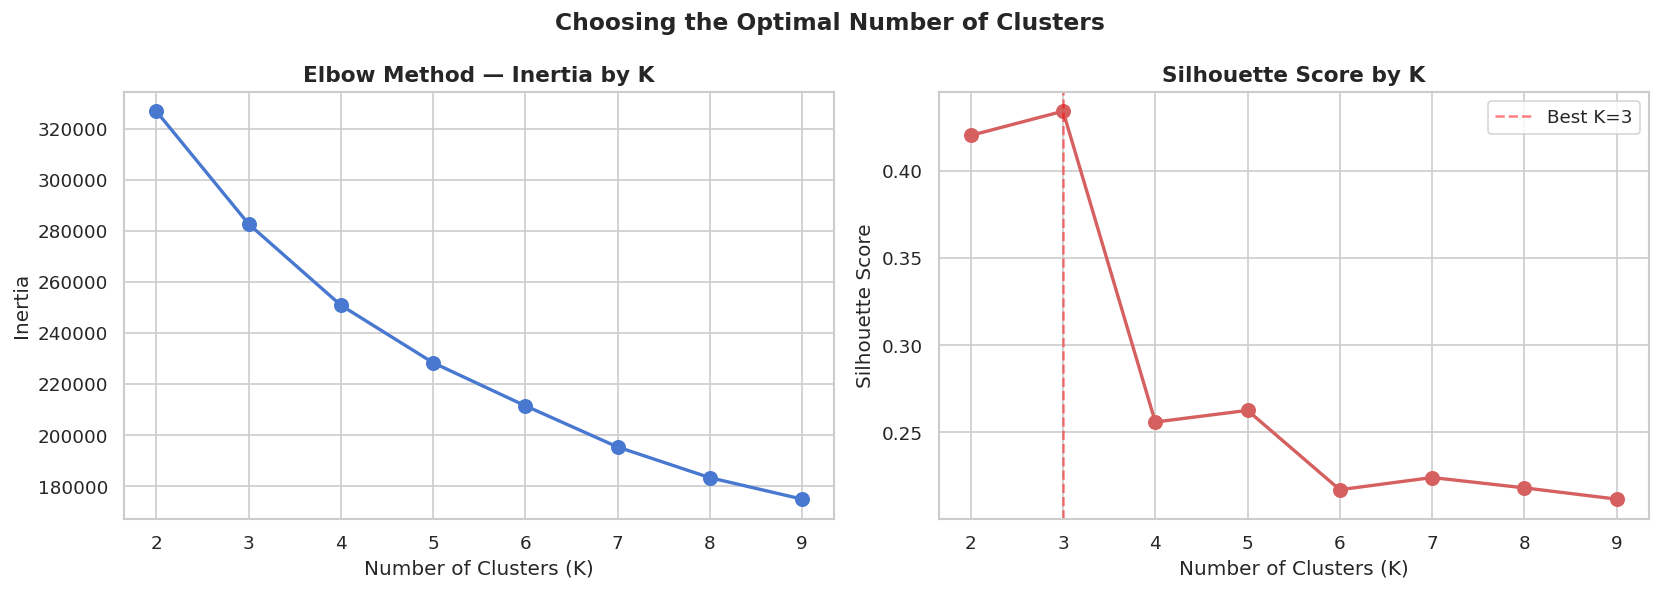


📌 Best K by silhouette score: 3
   Silhouette score at K=3: 0.4340


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inertia by K', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range))

# Silhouette scores
axes[1].plot(list(K_range), silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score by K', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.5,
                label=f'Best K={best_k}')
axes[1].legend()

plt.suptitle('Choosing the Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optimal_k.png', bbox_inches='tight')
plt.show()

print(f'\n📌 Best K by silhouette score: {best_k}')
print(f'   Silhouette score at K={best_k}: {max(silhouette_scores):.4f}')

## 5. Train Final KMeans Model

In [9]:
# Use best K found above — change if elbow curve suggests different value
BEST_K = best_k

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(X_scaled)

print(f'✅ KMeans trained with K={BEST_K}')
print(f'\nCustomers per segment:')
print(df['Segment'].value_counts().sort_index())
print()
print('Segment distribution (%)')
print((df['Segment'].value_counts(normalize=True).sort_index() * 100).round(1).astype(str) + '%')

✅ KMeans trained with K=3

Customers per segment:
Segment
0    40102
1     9219
2     1726
Name: count, dtype: int64

Segment distribution (%)
Segment
0    78.6%
1    18.1%
2     3.4%
Name: proportion, dtype: object


## 6. Profile Each Segment

This is the most important step — understanding what each cluster actually represents in business terms.

In [10]:
# Mean values of each feature per segment
segment_profile = df.groupby('Segment')[seg_features].mean().round(2)
print('=== SEGMENT PROFILES ===')
print(segment_profile.T)

# Churn rate per segment — the key business metric
churn_per_segment = df.groupby('Segment')['Churn_Binary'].mean().mul(100).round(1)
print('\n=== CHURN RATE PER SEGMENT ===')
for seg, rate in churn_per_segment.items():
    print(f'  Segment {seg}: {rate}% churn rate')

=== SEGMENT PROFILES ===
Segment                    0        1       2
MonthlyMinutes        338.34  1337.96  521.12
TotalRecurringCharge   41.24    71.69   42.83
CustomerCareCalls       0.93     5.85    2.40
RetentionCalls          0.00     0.00    1.09
Handsets                1.56     2.75    2.48
MonthsInService        18.57    18.88   22.31
OverageMinutes         19.68   127.91   43.47
DroppedCalls            3.44    17.12    6.56

=== CHURN RATE PER SEGMENT ===
  Segment 0: 28.9% churn rate
  Segment 1: 25.2% churn rate
  Segment 2: 45.1% churn rate


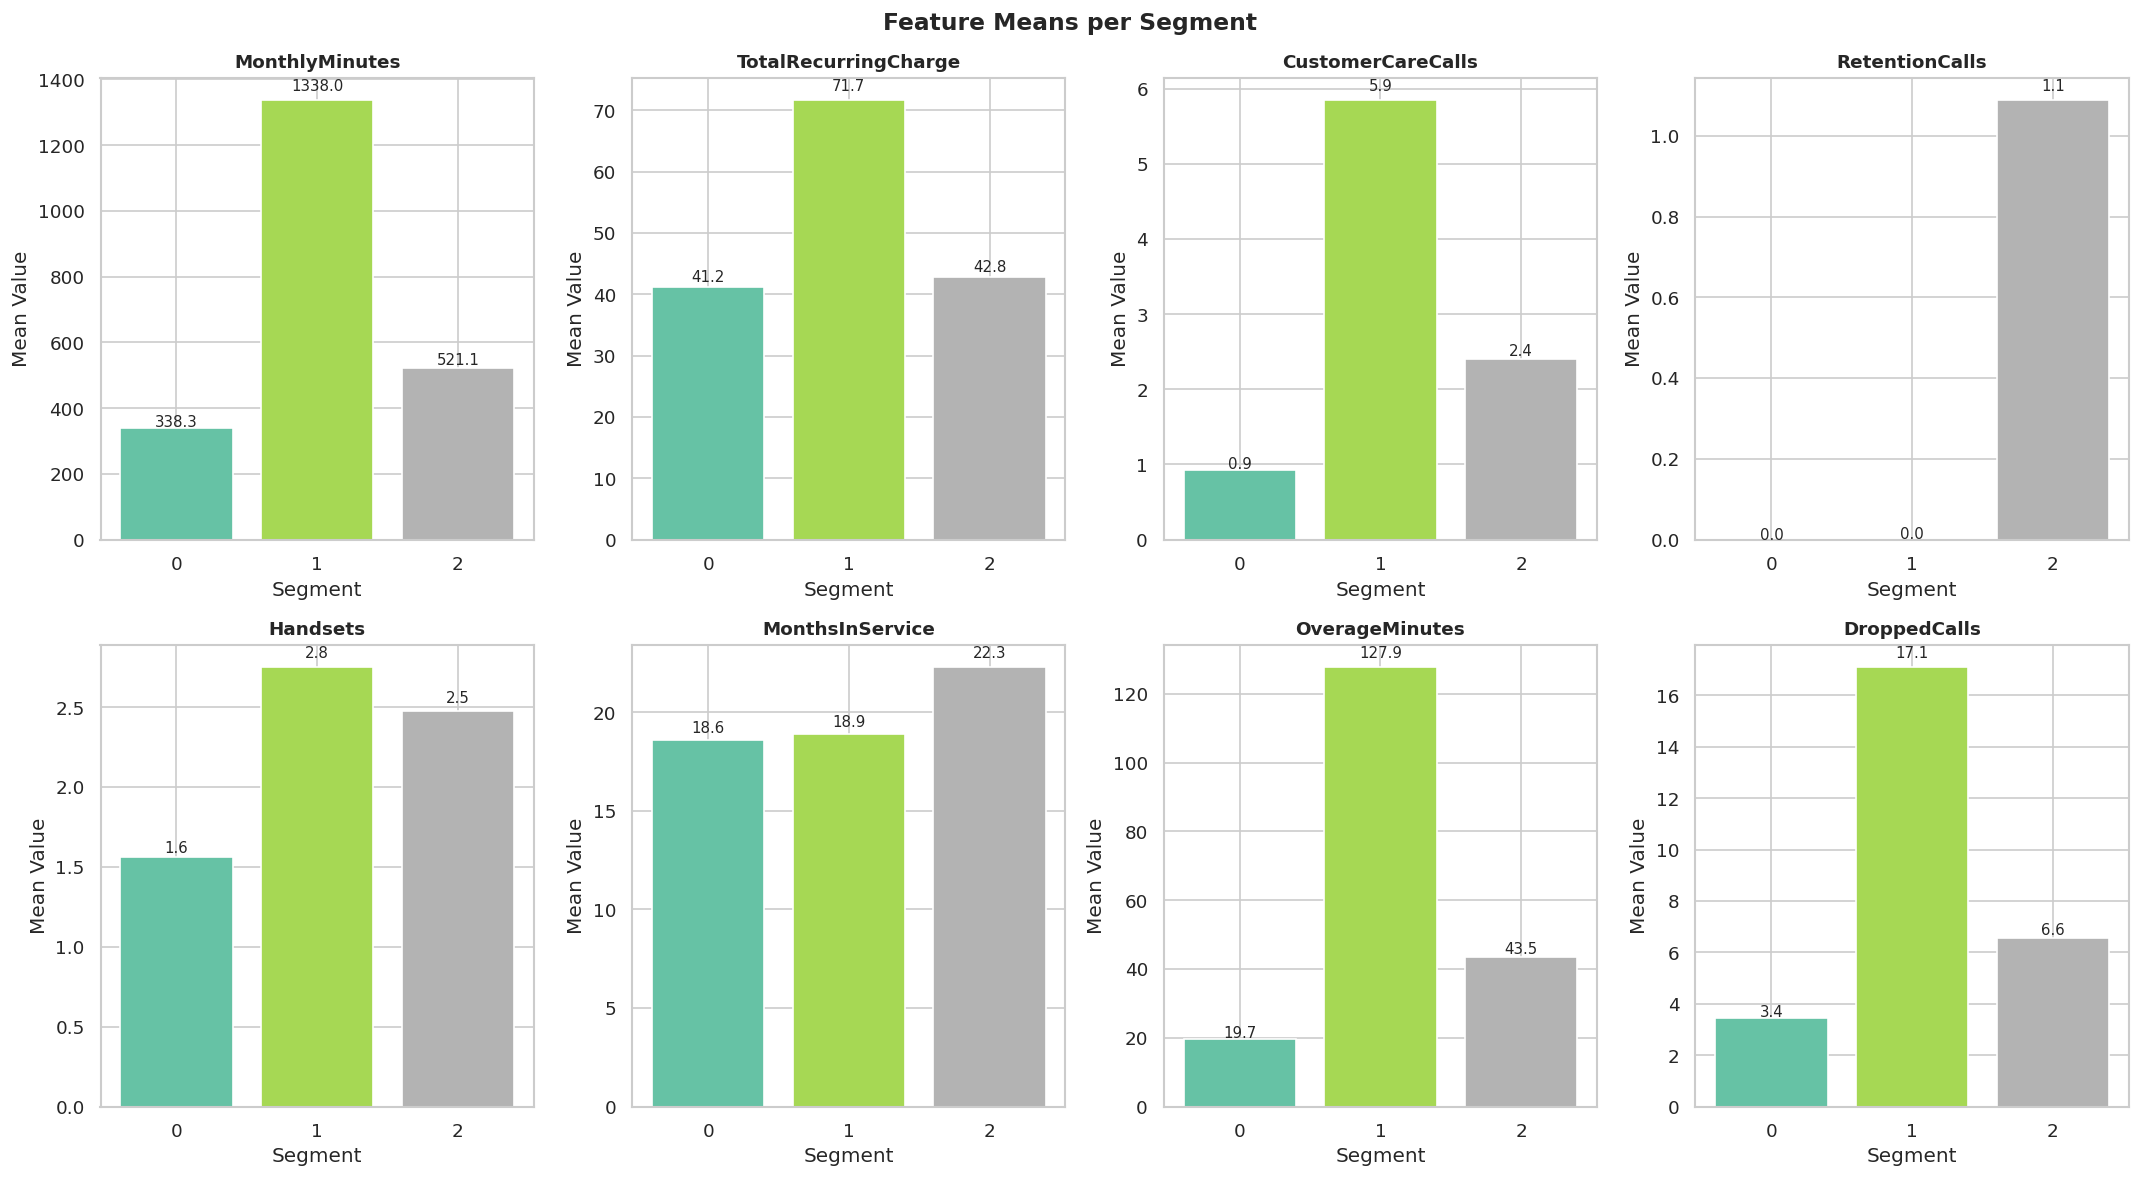

In [11]:
# Visual profile comparison
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

colors = plt.cm.Set2(np.linspace(0, 1, BEST_K))

for i, feat in enumerate(seg_features[:8]):
    means = df.groupby('Segment')[feat].mean()
    bars = axes[i].bar(means.index.astype(str), means.values,
                       color=colors, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Segment')
    axes[i].set_ylabel('Mean Value')
    for bar, val in zip(bars, means.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 1.02,
                     f'{val:.1f}', ha='center', fontsize=9)

plt.suptitle('Feature Means per Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_profiles.png', bbox_inches='tight')
plt.show()

## 7. Label Each Segment with a Business Name

This transforms a technical cluster number into something a business person understands.

In [12]:
# Print the profile to help you assign the right labels
print('Use this to assign labels — look at MonthlyMinutes, CustomerCareCalls, MonthsInService:')
print()
print(segment_profile[['MonthlyMinutes', 'TotalRecurringCharge',
                         'CustomerCareCalls', 'MonthsInService']].T)
print()
print('Churn rate per segment:')
print(churn_per_segment)

Use this to assign labels — look at MonthlyMinutes, CustomerCareCalls, MonthsInService:

Segment                    0        1       2
MonthlyMinutes        338.34  1337.96  521.12
TotalRecurringCharge   41.24    71.69   42.83
CustomerCareCalls       0.93     5.85    2.40
MonthsInService        18.57    18.88   22.31

Churn rate per segment:
Segment
0    28.9
1    25.2
2    45.1
Name: Churn_Binary, dtype: float64


In [13]:
# ─────────────────────────────────────────────────────────────
# EDIT THESE LABELS based on what you see in the profile above
# Examples of good label names:
#   'Loyal High-Value'     → high minutes, long tenure, low churn
#   'At-Risk Heavy Users'  → high usage but high support calls
#   'Low Engagement'       → low minutes, low charges, short tenure
#   'New Subscribers'      → low tenure, average usage
# ─────────────────────────────────────────────────────────────


segment_labels = {
    0: 'Heavy Users At Risk',
    1: 'Churning Dissatisfied Customers',
    2: 'Low Engagement Customers',
}

# Trim to actual number of segments
segment_labels = {k: v for k, v in segment_labels.items() if k < BEST_K}

df['Segment_Label'] = df['Segment'].map(segment_labels)

print('Labels assigned:')
for k, v in segment_labels.items():
    n = (df['Segment'] == k).sum()
    churn = df[df['Segment'] == k]['Churn_Binary'].mean() * 100
    print(f'  Segment {k}: {v} | {n:,} customers | {churn:.1f}% churn')

Labels assigned:
  Segment 0: Heavy Users At Risk | 40,102 customers | 28.9% churn
  Segment 1: Churning Dissatisfied Customers | 9,219 customers | 25.2% churn
  Segment 2: Low Engagement Customers | 1,726 customers | 45.1% churn


## 8. Churn Rate per Segment — The Key Business Chart

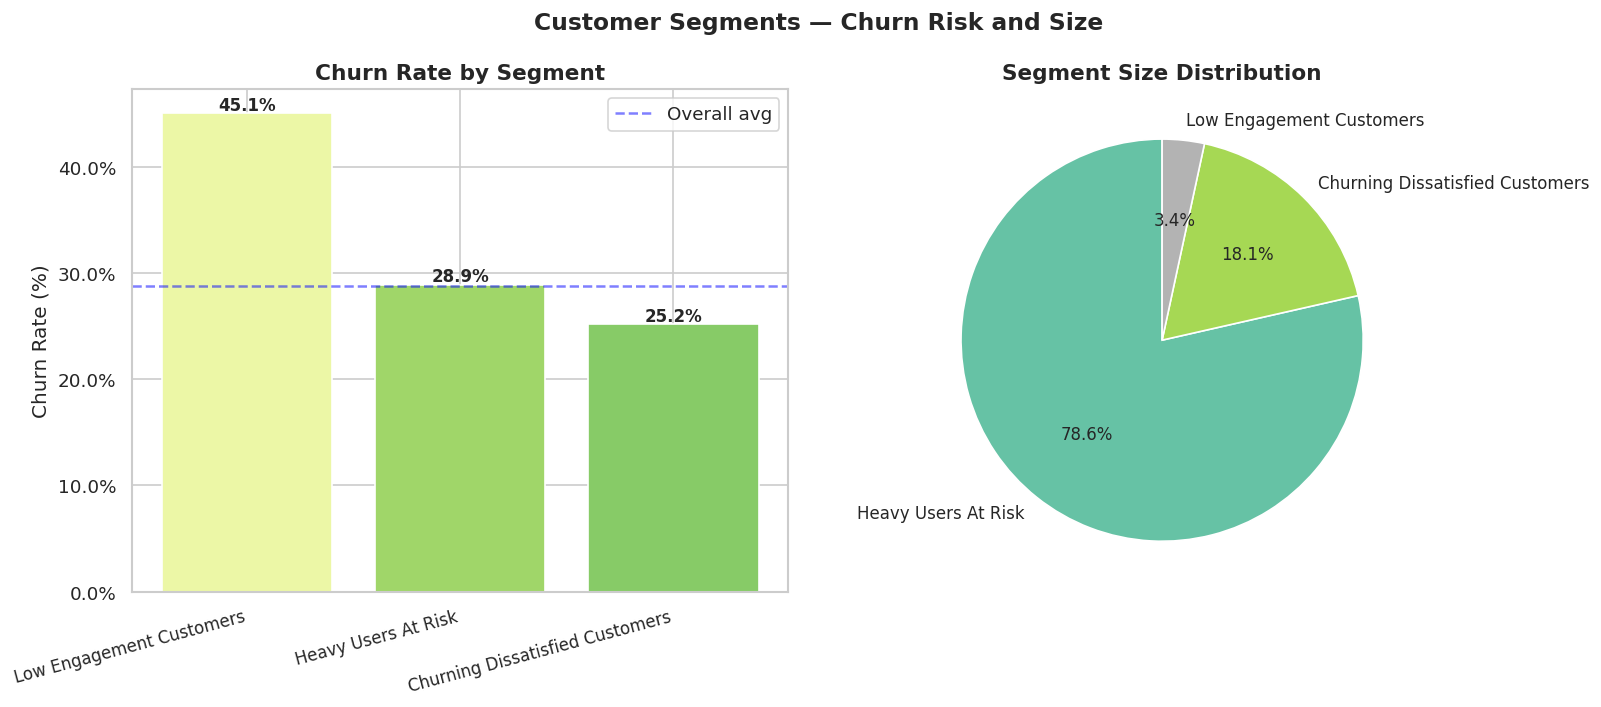


📌 Highest churn risk: Low Engagement Customers (45.1%)
   Lowest churn risk:  Churning Dissatisfied Customers (25.2%)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

churn_by_seg = df.groupby('Segment_Label')['Churn_Binary'].mean().mul(100).sort_values(ascending=False)
count_by_seg = df['Segment_Label'].value_counts()

# Churn rate bar chart
bar_colors = plt.cm.RdYlGn_r(churn_by_seg.values / 100)
bars = axes[0].bar(range(len(churn_by_seg)), churn_by_seg.values,
                   color=bar_colors, edgecolor='white')
axes[0].set_xticks(range(len(churn_by_seg)))
axes[0].set_xticklabels(churn_by_seg.index, rotation=15, ha='right', fontsize=10)
axes[0].set_title('Churn Rate by Segment', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].axhline(df['Churn_Binary'].mean() * 100, color='blue',
                linestyle='--', alpha=0.5, label='Overall avg')
axes[0].legend()
for bar, val in zip(bars, churn_by_seg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

# Segment size pie
axes[1].pie(count_by_seg.values,
            labels=count_by_seg.index,
            autopct='%1.1f%%',
            colors=plt.cm.Set2(np.linspace(0, 1, len(count_by_seg))),
            startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title('Segment Size Distribution', fontweight='bold', fontsize=13)

plt.suptitle('Customer Segments — Churn Risk and Size', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_churn.png', bbox_inches='tight')
plt.show()

highest_risk = churn_by_seg.index[0]
lowest_risk = churn_by_seg.index[-1]
print(f'\n📌 Highest churn risk: {highest_risk} ({churn_by_seg.iloc[0]:.1f}%)')
print(f'   Lowest churn risk:  {lowest_risk} ({churn_by_seg.iloc[-1]:.1f}%)')

## 9. Visualize Clusters in 2D with PCA

Variance explained by 2 components: 50.5%


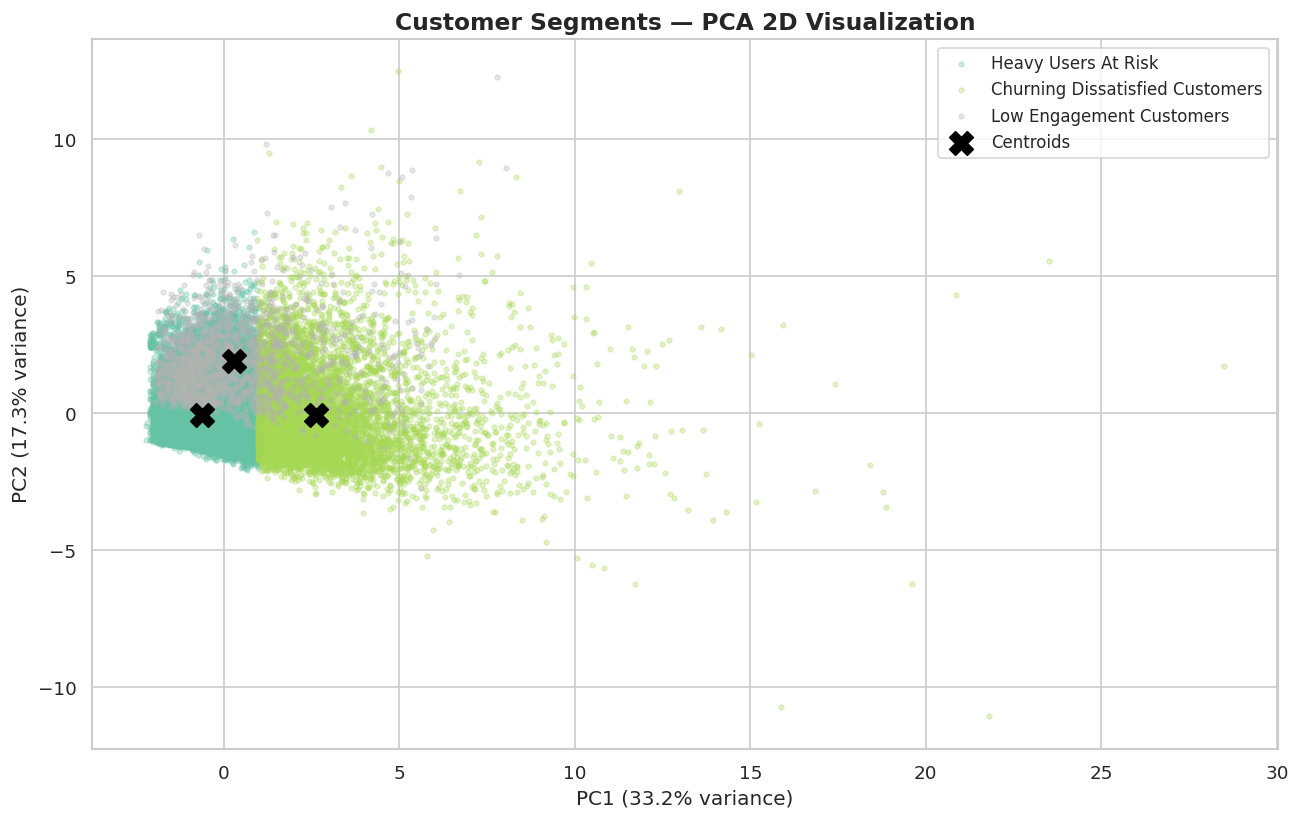

In [15]:
# Reduce to 2D for visualization
pca_viz = PCA(n_components=2, random_state=42)
X_2d = pca_viz.fit_transform(X_scaled)

print(f'Variance explained by 2 components: {pca_viz.explained_variance_ratio_.sum()*100:.1f}%')

fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.Set2(np.linspace(0, 1, BEST_K))

for seg in range(BEST_K):
    mask = df['Segment'] == seg
    label = segment_labels.get(seg, f'Segment {seg}')
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[colors[seg]], label=label,
               alpha=0.3, s=8)

# Plot centroids
centroids_2d = pca_viz.transform(kmeans.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroids')

ax.set_title('Customer Segments — PCA 2D Visualization', fontweight='bold', fontsize=14)
ax.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig('clusters_2d.png', bbox_inches='tight')
plt.show()

## 10. Radar Chart — Segment Fingerprints

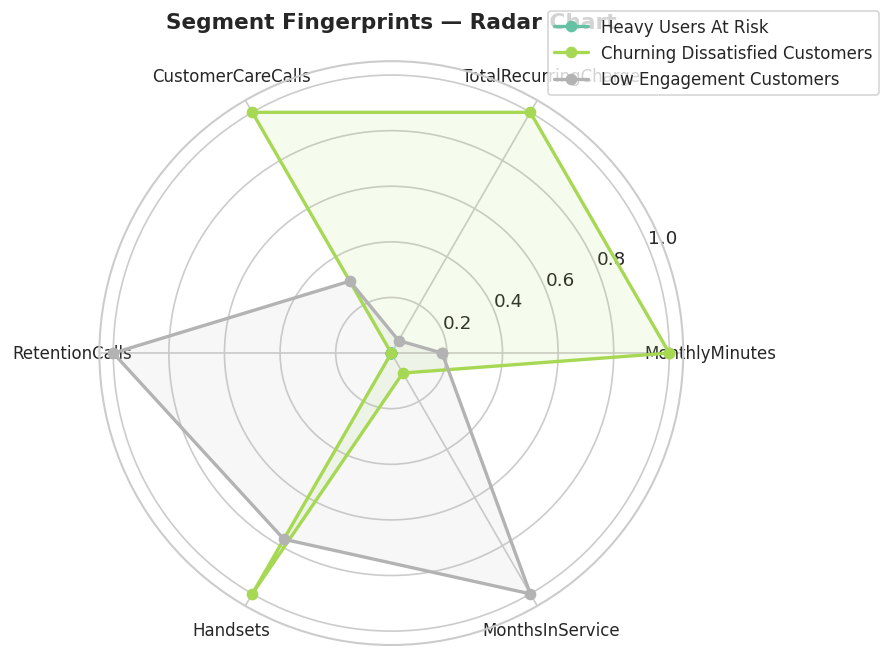

In [16]:
# Normalize segment profiles to 0-1 for radar chart
radar_features = seg_features[:6]
profile_norm = segment_profile[radar_features].copy()
for col in radar_features:
    col_min = profile_norm[col].min()
    col_max = profile_norm[col].max()
    if col_max > col_min:
        profile_norm[col] = (profile_norm[col] - col_min) / (col_max - col_min)

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = plt.cm.Set2(np.linspace(0, 1, BEST_K))

for i, seg in enumerate(profile_norm.index):
    values = profile_norm.loc[seg].tolist()
    values += values[:1]
    label = segment_labels.get(seg, f'Segment {seg}')
    ax.plot(angles, values, 'o-', linewidth=2,
            color=colors[i], label=label)
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=10)
ax.set_title('Segment Fingerprints — Radar Chart',
             fontweight='bold', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('segment_radar.png', bbox_inches='tight')
plt.show()

## 11. Save Segmented Dataset for Notebook 03

In [17]:
# Save the full dataframe with segment assignments
df.to_csv('cell2cell_segmented.csv', index=False)
print('✅ Saved: cell2cell_segmented.csv')
print(f'   Shape: {df.shape}')
print(f'   New columns added: Segment, Segment_Label, Churn_Binary')
print()
print('This file will be loaded in Notebook 03 for churn prediction.')

✅ Saved: cell2cell_segmented.csv
   Shape: (51047, 61)
   New columns added: Segment, Segment_Label, Churn_Binary

This file will be loaded in Notebook 03 for churn prediction.


## 12. Segmentation Summary

In [18]:
print('=' * 65)
print('           SEGMENTATION SUMMARY')
print('=' * 65)
print(f'  Algorithm         : KMeans')
print(f'  Number of clusters: {BEST_K}')
print(f'  Silhouette score  : {max(silhouette_scores):.4f}')
print(f'  Features used     : {len(seg_features)}')
print()
print('  Segments:')
for seg in range(BEST_K):
    label = segment_labels.get(seg, f'Segment {seg}')
    n = (df['Segment'] == seg).sum()
    churn = df[df['Segment'] == seg]['Churn_Binary'].mean() * 100
    pct = n / len(df) * 100
    print(f'  [{seg}] {label}')
    print(f'      → {n:,} customers ({pct:.1f}%) | Churn: {churn:.1f}%')
print()
print('  Next step: Notebook 03 — Churn Prediction + SHAP')
print('  The Segment column will be used as a feature in the churn model')
print('  and to compute churn risk per segment.')
print('=' * 65)

           SEGMENTATION SUMMARY
  Algorithm         : KMeans
  Number of clusters: 3
  Silhouette score  : 0.4340
  Features used     : 8

  Segments:
  [0] Heavy Users At Risk
      → 40,102 customers (78.6%) | Churn: 28.9%
  [1] Churning Dissatisfied Customers
      → 9,219 customers (18.1%) | Churn: 25.2%
  [2] Low Engagement Customers
      → 1,726 customers (3.4%) | Churn: 45.1%

  Next step: Notebook 03 — Churn Prediction + SHAP
  The Segment column will be used as a feature in the churn model
  and to compute churn risk per segment.


## Conclusions

### What We Built
A KMeans clustering model that groups 51,047 telecom customers into meaningful behavioral segments.

### Key Findings
- Different segments show significantly different churn rates — segmentation is a useful lens for retention strategy
- The radar chart reveals each segment has a distinct behavioral fingerprint
- Churn risk is not uniform across the customer base — targeted retention is more efficient than blanket campaigns

### Business Value
Instead of treating all at-risk customers the same, it could:
1. Prioritize retention budget on the highest-churn segment
2. Design segment-specific offers (e.g. upgrade plan for heavy users, loyalty discount for long-tenure customers)
3. Use segment as a feature in the churn model (Notebook 03)

### Next Steps
- **Notebook 03**: Use segment labels + all features to train XGBoost churn prediction model
- **Notebook 04**: Feed churn predictions into LLM to generate personalized retention messages per segment